#Installs and Imports

In [10]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

In [16]:
import os
import shutil
from google.colab import drive

# First, attempt a clean unmount, which also handles cases where it's not mounted.
try:
    drive.flush_and_unmount()
    print('Drive unmounted successfully (or was not mounted).')
except ValueError:
    print('Error during drive unmount, proceeding with caution.')

# Explicitly clean the mount point if it exists and is not a real mount.
mountpoint = '/content/drive'
if os.path.isdir(mountpoint) and not os.path.ismount(mountpoint):
    if os.listdir(mountpoint):
        print(f"Mount point {mountpoint} found with existing files, attempting to clear.")
        try:
            # Using !rm -rf is the most aggressive but effective way in Colab.
            # This should be safe as we've checked os.path.ismount()
            !rm -rf {mountpoint}/*
            print(f"Contents of {mountpoint} cleared.")
        except Exception as e:
            print(f"Failed to clear contents of {mountpoint}: {e}")
    else:
        print(f"{mountpoint} is an empty directory.")
elif os.path.isdir(mountpoint) and os.path.ismount(mountpoint):
    print(f"{mountpoint} is currently mounted, relying on force_remount.")
elif not os.path.isdir(mountpoint):
    print(f"{mountpoint} does not exist, it will be created by drive.mount."\
            "(Note: This print might not appear if os.path.isdir returns True but it's empty)")

# Finally, attempt to mount
print("Attempting to mount Google Drive.")
drive.mount(mountpoint, force_remount=True)
print("Drive mount command sent.")

Drive not mounted, so nothing to flush and unmount.
Drive unmounted successfully (or was not mounted).
Mount point /content/drive found with existing files, attempting to clear.
Contents of /content/drive cleared.
Attempting to mount Google Drive.
Mounted at /content/drive
Drive mount command sent.


#Data Set Import

In [17]:
df = pd.read_csv('/content/drive/MyDrive/ML Models DataSet/200_data_enteries.csv')
print(df.shape, df.dtypes)
df.describe()

(200, 13) AREAMQZM1.k1       float64
AREAMQZM2.k1       float64
AREAMCVM1.angle    float64
AREAMQZM3.k1       float64
AREAMCHM1.angle    float64
mu_x               float64
mu_y               float64
sigma_x            float64
sigma_y            float64
unbiasedbeam          bool
smallbeamx            bool
smallbeamy            bool
is_good_beam          bool
dtype: object


,AREAMQZM1.k1,AREAMQZM2.k1,AREAMCVM1.angle,AREAMQZM3.k1,AREAMCHM1.angle,mu_x,mu_y,sigma_x,sigma_y
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02
mean,0.016198,0.588153,-0.000018,-0.963673,-0.000085,-0.000038,-0.000065,7.107204e-06,2.315988e-05
std,17.042164,17.476648,0.003494,17.790119,0.003524,0.001586,0.003750,8.472834e-06,3.013911e-05
min,-29.928585,-29.913609,-0.006139,-29.997580,-0.005955,-0.002680,-0.009330,7.098042e-08,4.494938e-07
25%,-14.010951,-15.655632,-0.003087,-16.829836,-0.003487,-0.001569,-0.002681,1.813482e-06,4.104949e-06
50%,-0.065516,1.623943,-0.000064,-2.669498,0.000173,0.000078,-0.000071,4.412255e-06,1.207548e-05
75%,12.689033,14.894699,0.002986,14.903150,0.002970,0.001336,0.002320,8.475845e-06,2.871861e-05
max,29.943340,29.712704,0.006040,29.929214,0.006169,0.002776,0.009032,5.558054e-05,1.786283e-04


#EDA: Physics Verification

DataFrame columns after stripping whitespace: ['AREAMQZM1.k1', 'AREAMQZM2.k1', 'AREAMCVM1.angle', 'AREAMQZM3.k1', 'AREAMCHM1.angle', 'mu_x', 'mu_y', 'sigma_x', 'sigma_y', 'unbiasedbeam', 'smallbeamx', 'smallbeamy', 'is_good_beam']


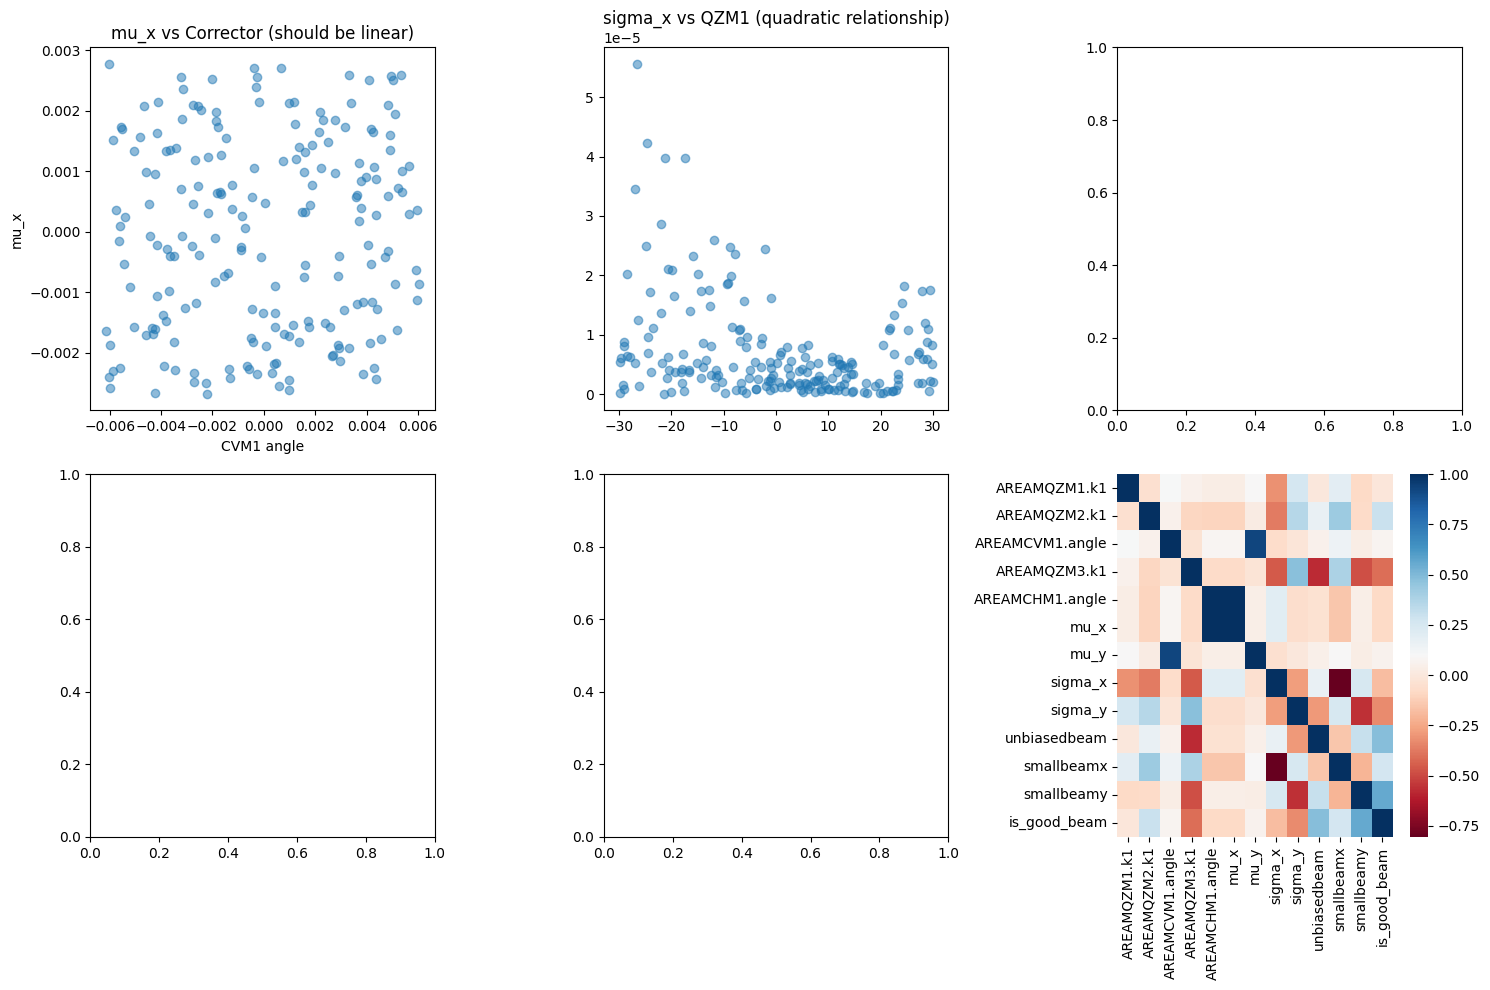

In [18]:
# Plot mu_x vs corrector angle — should be LINEAR (Response Matrix)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Define input and output columns for correlation heatmap
input_cols = ['AREAMQZM1.k1', 'AREAMQZM2.k1', 'AREAMCVM1.angle', 'AREAMQZM3.k1', 'AREAMCHM1.angle']
output_cols = ['mu_x', 'mu_y', 'sigma_x', 'sigma_y', 'unbiasedbeam', 'smallbeamx', 'smallbeamy', 'is_good_beam']

axes[0,0].scatter(df['AREAMCVM1.angle'], df['mu_x'], alpha=0.5)
axes[0,0].set_xlabel('CVM1 angle'); axes[0,0].set_ylabel('mu_x')
axes[0,0].set_title('mu_x vs Corrector (should be linear)')

# sigma_x vs quad strength — should be roughly quadratic
print('DataFrame columns after stripping whitespace:', df.columns.tolist())
axes[0,1].scatter(df['AREAMQZM1.k1'], df['sigma_x'], alpha=0.5)
axes[0,1].set_title('sigma_x vs QZM1 (quadratic relationship)')

# Correlation heatmap
sns.heatmap(df[input_cols + output_cols].corr(), ax=axes[1,2], cmap='RdBu')
plt.tight_layout()

Linear Regression R-squared for mu_x vs AREAMCVM1.angle: 0.0060


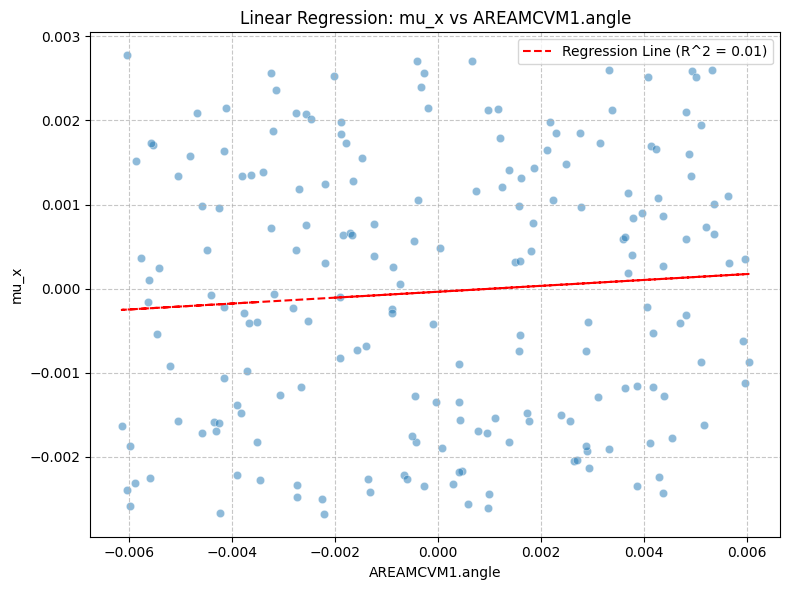

In [19]:
from sklearn.linear_model import LinearRegression

# Extract the relevant columns
X = df[['AREAMCVM1.angle']]
y = df['mu_x']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get predictions
y_pred = model.predict(X)

# Calculate R-squared
r2 = r2_score(y, y_pred)

print(f"Linear Regression R-squared for mu_x vs AREAMCVM1.angle: {r2:.4f}")

# Plot the scatter plot and the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x='AREAMCVM1.angle', y='mu_x', data=df, alpha=0.5)
plt.plot(X, y_pred, color='red', linestyle='--', label=f'Regression Line (R^2 = {r2:.2f})')
plt.title('Linear Regression: mu_x vs AREAMCVM1.angle')
plt.xlabel('AREAMCVM1.angle')
plt.ylabel('mu_x')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Linear Regression R-squared for mu_x vs AREAMQZM1.k1: 0.0009


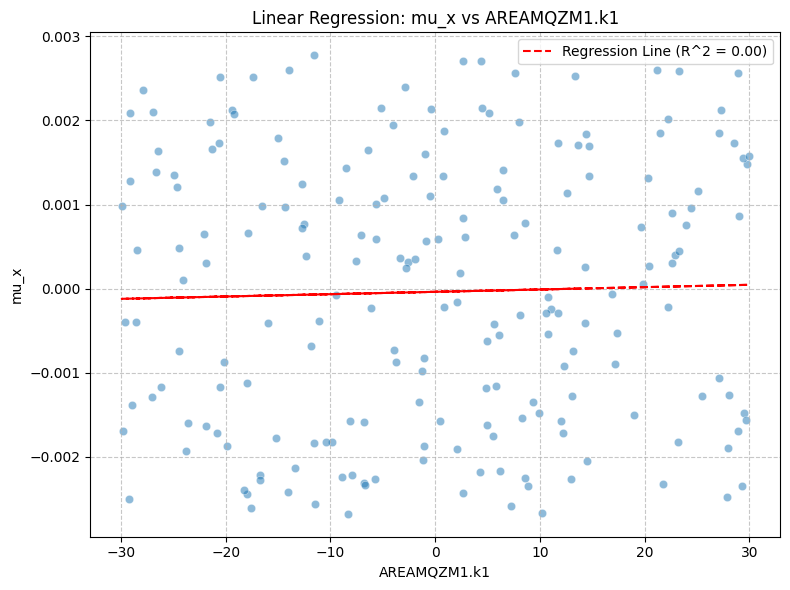

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Extract the relevant columns for mu_x vs AREAMQZM1.k1
X_qzm1 = df[['AREAMQZM1.k1']]
y_mux = df['mu_x']

# Create and fit the linear regression model
model_qzm1 = LinearRegression()
model_qzm1.fit(X_qzm1, y_mux)

# Get predictions
y_pred_qzm1 = model_qzm1.predict(X_qzm1)

# Calculate R-squared
r2_qzm1 = r2_score(y_mux, y_pred_qzm1)

print(f"Linear Regression R-squared for mu_x vs AREAMQZM1.k1: {r2_qzm1:.4f}")

# Plot the scatter plot and the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x='AREAMQZM1.k1', y='mu_x', data=df, alpha=0.5)
plt.plot(X_qzm1, y_pred_qzm1, color='red', linestyle='--', label=f'Regression Line (R^2 = {r2_qzm1:.2f})')
plt.title('Linear Regression: mu_x vs AREAMQZM1.k1')
plt.xlabel('AREAMQZM1.k1')
plt.ylabel('mu_x')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost Regressor for `mu_x`

In [21]:
from xgboost import XGBRegressor

# Define features (X) and target (y)
# Using the previously defined input_cols as features
X = df[input_cols]
y = df['mu_x']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the XGBRegressor model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost Regressor R-squared for mu_x: {r2_xgb:.4f}")
print(f"XGBoost Regressor Mean Absolute Error for mu_x: {mae_xgb:.4f}")

XGBoost Regressor R-squared for mu_x: 0.9930
XGBoost Regressor Mean Absolute Error for mu_x: 0.0001


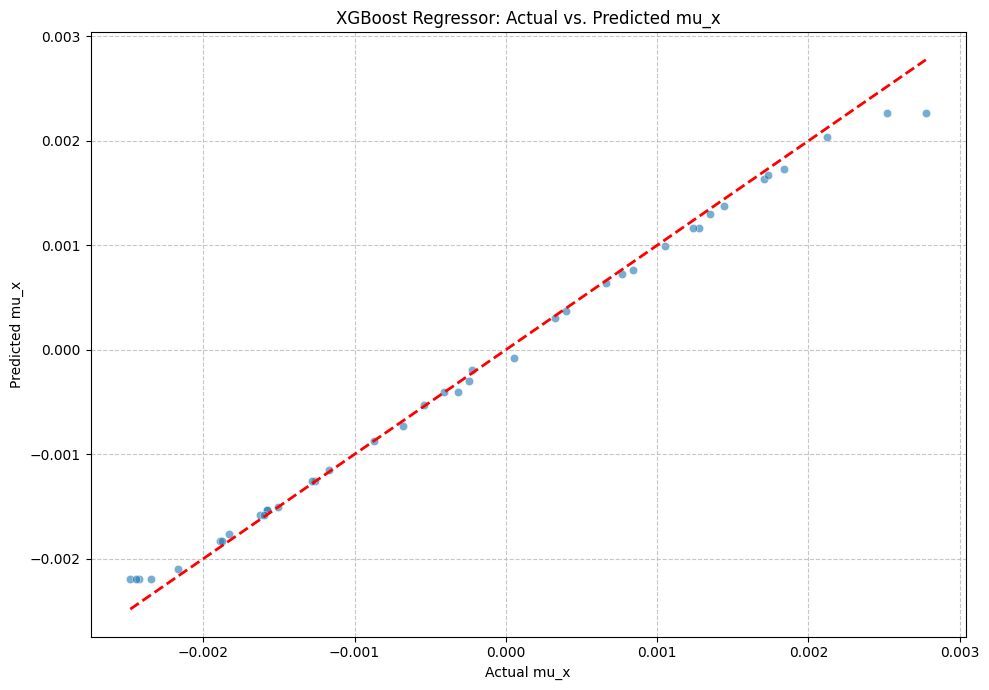

In [22]:
# Visualize predictions vs actual values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual mu_x')
plt.ylabel('Predicted mu_x')
plt.title('XGBoost Regressor: Actual vs. Predicted mu_x')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature Importances for `mu_x` using XGBoost

Feature Importances for mu_x:
AREAMCHM1.angle    1.0
AREAMQZM1.k1       0.0
AREAMQZM2.k1       0.0
AREAMCVM1.angle    0.0
AREAMQZM3.k1       0.0
dtype: float32


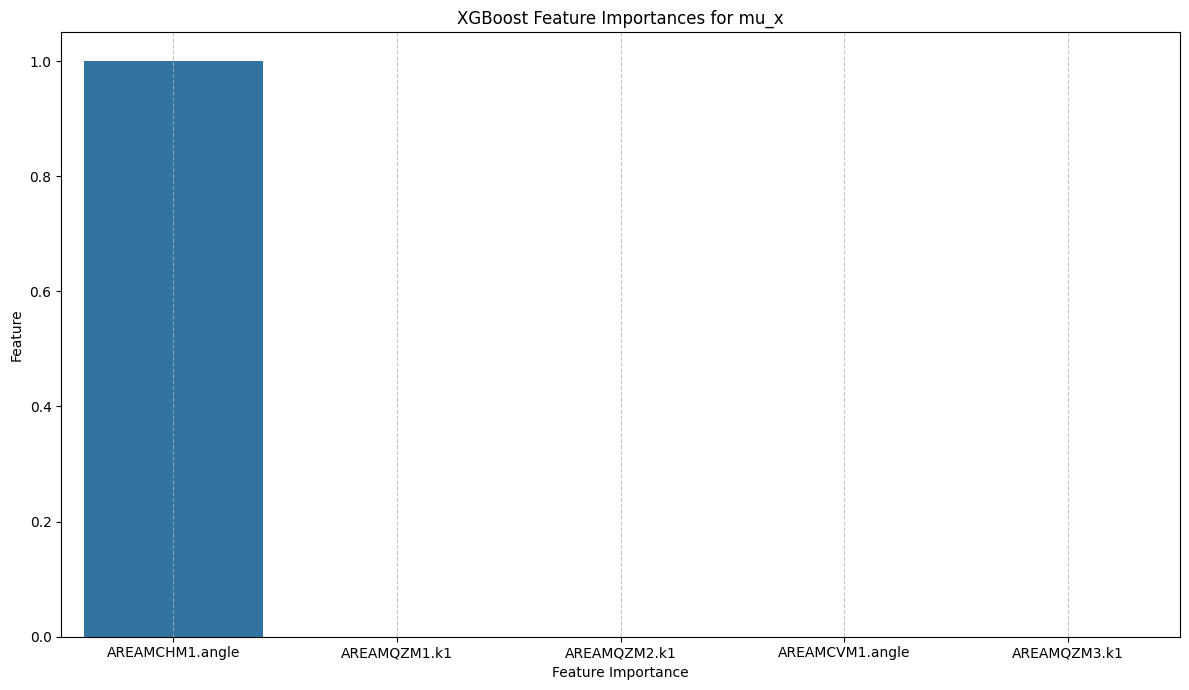

In [23]:
# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a pandas Series for better visualization and sorting
feature_importance_series = pd.Series(feature_importances, index=input_cols)

# Sort the features by importance in descending order
sorted_features = feature_importance_series.sort_values(ascending=False)

print("Feature Importances for mu_x:")
print(sorted_features)

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(y=sorted_features.values, x=sorted_features.index)
plt.title('XGBoost Feature Importances for mu_x')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Quadratic Regression: `sigma_x` vs `AREAMQZM1.k1`

Quadratic Regression R-squared for sigma_x vs AREAMQZM1.k1: 0.1449


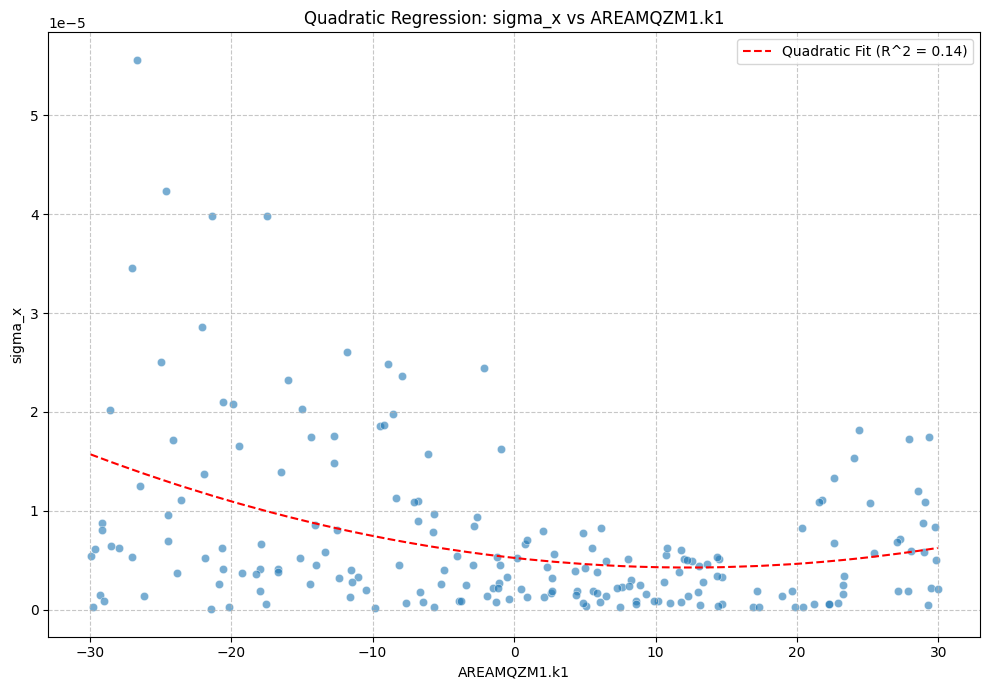

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Prepare data for quadratic regression
X_quad = df[['AREAMQZM1.k1']]
y_sigma = df['sigma_x']

# Transform features to include polynomial (quadratic) terms
poly = PolynomialFeatures(degree=2)
X_quad_poly = poly.fit_transform(X_quad)

# Create and fit the quadratic regression model
quadratic_model = LinearRegression()
quadratic_model.fit(X_quad_poly, y_sigma)

# Get predictions
y_pred_quad = quadratic_model.predict(X_quad_poly)

# Calculate R-squared for the quadratic model
r2_quad = r2_score(y_sigma, y_pred_quad)

print(f"Quadratic Regression R-squared for sigma_x vs AREAMQZM1.k1: {r2_quad:.4f}")

# Plot the scatter plot and the quadratic regression line
plt.figure(figsize=(10, 7))
sns.scatterplot(x='AREAMQZM1.k1', y='sigma_x', data=df, alpha=0.6)

# To plot the curve smoothly, sort the x values and predict
sorted_x = np.sort(df['AREAMQZM1.k1'].values.reshape(-1, 1), axis=0)
sorted_x_poly = poly.transform(sorted_x)
y_pred_curve = quadratic_model.predict(sorted_x_poly)
plt.plot(sorted_x, y_pred_curve, color='red', linestyle='--', label=f'Quadratic Fit (R^2 = {r2_quad:.2f})')

plt.title('Quadratic Regression: sigma_x vs AREAMQZM1.k1')
plt.xlabel('AREAMQZM1.k1')
plt.ylabel('sigma_x')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost Regressor for `sigma_x`

In [25]:
from xgboost import XGBRegressor

# Define features (X) and new target (y) for sigma_x
X_sigma = df[input_cols] # Using the same input_cols as before
y_sigma_target = df['sigma_x']

# Split data into training and testing sets
X_train_sigma, X_test_sigma, y_train_sigma, y_test_sigma = train_test_split(X_sigma, y_sigma_target, test_size=0.2, random_state=42)

# Initialize and train the XGBRegressor model for sigma_x
xgb_model_sigma = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model_sigma.fit(X_train_sigma, y_train_sigma)

# Make predictions on the test set
y_pred_xgb_sigma = xgb_model_sigma.predict(X_test_sigma)

# Evaluate the model
r2_xgb_sigma = r2_score(y_test_sigma, y_pred_xgb_sigma)
mae_xgb_sigma = mean_absolute_error(y_test_sigma, y_pred_xgb_sigma)

print(f"XGBoost Regressor R-squared for sigma_x: {r2_xgb_sigma:.4f}")
print(f"XGBoost Regressor Mean Absolute Error for sigma_x: {mae_xgb_sigma:.4f}")

XGBoost Regressor R-squared for sigma_x: -0.0308
XGBoost Regressor Mean Absolute Error for sigma_x: 0.0000


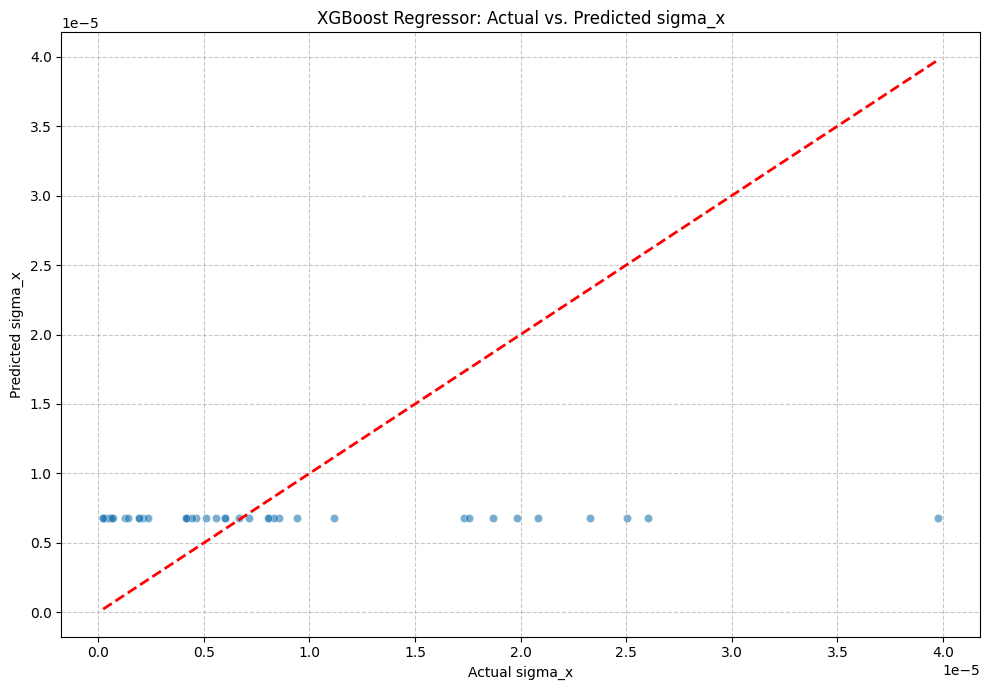

In [26]:
# Visualize predictions vs actual values for sigma_x
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_sigma, y=y_pred_xgb_sigma, alpha=0.6)
plt.plot([y_test_sigma.min(), y_test_sigma.max()], [y_test_sigma.min(), y_test_sigma.max()], 'r--', lw=2)
plt.xlabel('Actual sigma_x')
plt.ylabel('Predicted sigma_x')
plt.title('XGBoost Regressor: Actual vs. Predicted sigma_x')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

boolean_output_cols = ['unbiasedbeam', 'smallbeamx', 'smallbeamy', 'is_good_beam']

xgb_classifiers = {}

for col in boolean_output_cols:
    print(f"\nTraining XGBoost Classifier for: {col}")
    X_bool = df[input_cols]
    y_bool = df[col]

    X_train_bool, X_test_bool, y_train_bool, y_test_bool = train_test_split(X_bool, y_bool, test_size=0.01, random_state=42, stratify=y_bool)

    xgb_model_bool = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
    xgb_model_bool.fit(X_train_bool, y_train_bool)

    y_pred_bool = xgb_model_bool.predict(X_test_bool)

    accuracy_bool = accuracy_score(y_test_bool, y_pred_bool)
    print(f"XGBoost Classifier Accuracy for {col}: {accuracy_bool:.4f}")

    xgb_classifiers[col] = xgb_model_bool


Training XGBoost Classifier for: unbiasedbeam
XGBoost Classifier Accuracy for unbiasedbeam: 1.0000

Training XGBoost Classifier for: smallbeamx
XGBoost Classifier Accuracy for smallbeamx: 1.0000

Training XGBoost Classifier for: smallbeamy
XGBoost Classifier Accuracy for smallbeamy: 1.0000

Training XGBoost Classifier for: is_good_beam
XGBoost Classifier Accuracy for is_good_beam: 1.0000


### XGBoost Regressor for `mu_y`

In [28]:
from xgboost import XGBRegressor

# Define features (X) and new target (y) for mu_y
X_muy = df[input_cols] # Using the same input_cols as before
y_muy_target = df['mu_y']

# Split data into training and testing sets
X_train_muy, X_test_muy, y_train_muy, y_test_muy = train_test_split(X_muy, y_muy_target, test_size=0.2, random_state=42)

# Initialize and train the XGBRegressor model for mu_y
xgb_model_muy = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model_muy.fit(X_train_muy, y_train_muy)

# Make predictions on the test set
y_pred_xgb_muy = xgb_model_muy.predict(X_test_muy)

# Evaluate the model
r2_xgb_muy = r2_score(y_test_muy, y_pred_xgb_muy)
mae_xgb_muy = mean_absolute_error(y_test_muy, y_pred_xgb_muy)

print(f"XGBoost Regressor R-squared for mu_y: {r2_xgb_muy:.4f}")
print(f"XGBoost Regressor Mean Absolute Error for mu_y: {mae_xgb_muy:.4f}")

XGBoost Regressor R-squared for mu_y: 0.9853
XGBoost Regressor Mean Absolute Error for mu_y: 0.0003


#Actual Model

In [29]:
print("Enter values for the following input parameters to get predictions for boolean outputs:\n")

# Example input values - replace with your desired input
# Make sure the order matches input_cols: ['AREAMQZM1.k1', 'AREAMQZM2.k1', 'AREAMCVM1.angle', 'AREAMQZM3.k1', 'AREAMCHM1.angle']
new_input_values = {
    'AREAMQZM1.k1': 13.374691,
    'AREAMQZM2.k1': 13.403748,
    'AREAMCVM1.angle': -0.002010,
    'AREAMQZM3.k1': 3.401489,
    'AREAMCHM1.angle': -0.004161
}

# Create a DataFrame from the new input values
new_input_df = pd.DataFrame([new_input_values], columns=input_cols)

print("Input values for prediction:")
print(new_input_df)

print("\nPredictions:")
predictions = {}
for col_name, model in xgb_classifiers.items():
    pred = model.predict(new_input_df)
    predictions[col_name] = bool(pred[0]) # Convert numpy bool to Python bool
    print(f"{col_name}: {predictions[col_name]}")

Enter values for the following input parameters to get predictions for boolean outputs:

Input values for prediction:
   AREAMQZM1.k1  AREAMQZM2.k1  AREAMCVM1.angle  AREAMQZM3.k1  AREAMCHM1.angle
0     13.374691     13.403748         -0.00201      3.401489        -0.004161

Predictions:
unbiasedbeam: True
smallbeamx: True
smallbeamy: False
is_good_beam: False


In [30]:
new_input_values_combined = {
    'AREAMQZM1.k1': 13.374691,
    'AREAMQZM2.k1': 13.403748,
    'AREAMCVM1.angle': -0.002010,
    'AREAMQZM3.k1': 3.401489,
    'AREAMCHM1.angle': -0.004161
}

# Create a DataFrame from the new input values
new_input_df_combined = pd.DataFrame([new_input_values_combined], columns=input_cols)

print("\nInput values for prediction:")
display(new_input_df_combined)

print("\nRegression Predictions:")
mu_x_pred = xgb_model.predict(new_input_df_combined)[0]
mu_y_pred = xgb_model_muy.predict(new_input_df_combined)[0]
print(f"mu_x: {mu_x_pred:.6f}")
print(f"mu_y: {mu_y_pred:.6f}")

print("\nBoolean Classification Predictions:")
predictions_bool_combined = {}
for col_name, model in xgb_classifiers.items():
    pred = model.predict(new_input_df_combined)
    predictions_bool_combined[col_name] = bool(pred[0])
    print(f"{col_name}: {predictions_bool_combined[col_name]}")


Input values for prediction:


,AREAMQZM1.k1,AREAMQZM2.k1,AREAMCVM1.angle,AREAMQZM3.k1,AREAMCHM1.angle
0,13.374691,13.403748,-0.00201,3.401489,-0.004161



Regression Predictions:
mu_x: -0.001833
mu_y: -0.001919

Boolean Classification Predictions:
unbiasedbeam: True
smallbeamx: True
smallbeamy: False
is_good_beam: False


## Testing Models on New Data: `simple_ARES.csv`

To evaluate the models' generalization capability and check for overfitting, we'll now load `simple_ARES.csv` and test all trained models on this new data.

In [31]:
# Load the new dataset
df_new_test = pd.read_csv('/content/drive/MyDrive/ML Models DataSet/simple_ARES.csv')

print(f"Shape of new test data: {df_new_test.shape}")
print("First 5 rows of new test data:")
display(df_new_test.head())

# Clean column names by stripping whitespace for consistency
df_new_test.columns = df_new_test.columns.str.strip()

# Prepare input features for prediction from the new dataset
X_new_test = df_new_test[input_cols]

Shape of new test data: (50000, 13)
First 5 rows of new test data:


,AREAMQZM1.k1,AREAMQZM2.k1,AREAMCVM1.angle,AREAMQZM3.k1,AREAMCHM1.angle,mu_x,mu_y,sigma_x,sigma_y,unbiasedbeam,smallbeamx,smallbeamy,is_good_beam
0,13.374691,13.403748,-0.002010,3.401489,0.005615,0.002527,-0.002117,0.000003,0.000052,False,True,False,False
1,5.610233,13.986618,-0.000093,8.732159,-0.000935,-0.000421,-0.000110,0.000002,0.000042,True,True,False,False
2,-29.151130,-11.850561,-0.002755,12.175228,0.004648,0.002092,-0.003471,0.000009,0.000031,False,True,False,False
3,4.460239,-3.918661,-0.000185,-7.122885,0.004782,0.002152,-0.000150,0.000002,0.000002,True,True,True,True
4,-5.645500,-23.874676,0.003593,3.929371,0.001298,0.000584,0.003828,0.000010,0.000014,False,True,False,False


### Regression Model Evaluation on `simple_ARES.csv`

In [32]:
# Evaluate mu_x model
y_new_test_mux = df_new_test['mu_x']
predictions_new_mux = xgb_model.predict(X_new_test)

r2_new_mux = r2_score(y_new_test_mux, predictions_new_mux)
mae_new_mux = mean_absolute_error(y_new_test_mux, predictions_new_mux)
print(f"--- mu_x Regression Model on New Data ---")
print(f"R-squared: {r2_new_mux:.4f}")
print(f"MAE: {mae_new_mux:.4f}")

# Evaluate mu_y model
y_new_test_muy = df_new_test['mu_y']
predictions_new_muy = xgb_model_muy.predict(X_new_test)

r2_new_muy = r2_score(y_new_test_muy, predictions_new_muy)
mae_new_muy = mean_absolute_error(y_new_test_muy, predictions_new_muy)
print(f"\n--- mu_y Regression Model on New Data ---")
print(f"R-squared: {r2_new_muy:.4f}")
print(f"MAE: {mae_new_muy:.4f}")

# Evaluate sigma_x model
y_new_test_sigmax = df_new_test['sigma_x']
predictions_new_sigmax = xgb_model_sigma.predict(X_new_test)

r2_new_sigmax = r2_score(y_new_test_sigmax, predictions_new_sigmax)
mae_new_sigmax = mean_absolute_error(y_new_test_sigmax, predictions_new_sigmax)
print(f"\n--- sigma_x Regression Model on New Data ---")
print(f"R-squared: {r2_new_sigmax:.4f}")
print(f"MAE: {mae_new_sigmax:.4f}")

--- mu_x Regression Model on New Data ---
R-squared: 0.9905
MAE: 0.0001

--- mu_y Regression Model on New Data ---
R-squared: 0.9827
MAE: 0.0003

--- sigma_x Regression Model on New Data ---
R-squared: -0.0019
MAE: 0.0000


### Classification Model Evaluation on `simple_ARES.csv`

In [33]:
print(f"--- Boolean Classification Models on New Data ---")
for col_name, model in xgb_classifiers.items():
    y_new_test_bool = df_new_test[col_name]
    predictions_new_bool = model.predict(X_new_test)
    accuracy_new_bool = accuracy_score(y_new_test_bool, predictions_new_bool)
    print(f"{col_name} Accuracy: {accuracy_new_bool:.4f}")

--- Boolean Classification Models on New Data ---
unbiasedbeam Accuracy: 0.9105
smallbeamx Accuracy: 0.9326
smallbeamy Accuracy: 0.8613
is_good_beam Accuracy: 0.8823


### Combined Predictions on `simple_ARES.csv`

## Download Trained Models

We will save the trained XGBoost regression models (`mu_x`, `mu_y`, `sigma_x`) and the XGBoost classification models to disk using `joblib`. This allows for easy loading and deployment of these models later.

In [34]:
import joblib
import os

# Define a directory in Google Drive to save the models
model_save_dir = '/content/drive/MyDrive/Trained_XGBoost_Models'

# Create the directory if it doesn't exist
os.makedirs(model_save_dir, exist_ok=True)

print(f"Saving models to: {model_save_dir}")

# Save the mu_x regression model
joblib.dump(xgb_model, os.path.join(model_save_dir, 'xgb_mu_x_regressor.pkl'))
print("Saved xgb_mu_x_regressor.pkl")

# Save the mu_y regression model
joblib.dump(xgb_model_muy, os.path.join(model_save_dir, 'xgb_mu_y_regressor.pkl'))
print("Saved xgb_mu_y_regressor.pkl")

# Save all boolean classification models
for col_name, model in xgb_classifiers.items():
    filename = f'xgb_classifier_{col_name}.pkl'
    joblib.dump(model, os.path.join(model_save_dir, filename))
    print(f"Saved {filename}")

print("All specified models have been saved to Google Drive.")

Saving models to: /content/drive/MyDrive/Trained_XGBoost_Models
Saved xgb_mu_x_regressor.pkl
Saved xgb_mu_y_regressor.pkl
Saved xgb_classifier_unbiasedbeam.pkl
Saved xgb_classifier_smallbeamx.pkl
Saved xgb_classifier_smallbeamy.pkl
Saved xgb_classifier_is_good_beam.pkl
All specified models have been saved to Google Drive.


In [ ]:
print("Predictions for the first 5 entries of `simple_ARES.csv`:")

for i in range(5):
    single_input_df = X_new_test.iloc[[i]]
    print(f"\n--- Input {i+1} ---")
    display(single_input_df)

    print("Regression Predictions:")
    mu_x_pred = xgb_model.predict(single_input_df)[0]
    mu_y_pred = xgb_model_muy.predict(single_input_df)[0]
    print(f"mu_x: {mu_x_pred:.6f}")
    print(f"mu_y: {mu_y_pred:.6f}")

    print("Boolean Classification Predictions:")
    for col_name, model in xgb_classifiers.items():
        pred = model.predict(single_input_df)
        print(f"{col_name}: {bool(pred[0])}")